# Forest Cover Type Prediction
#### Uyenmy Nguyen
#### Research Question: Which tree type would cover best in a specific wilderness according to its characteristics?

**Best Model: SMOTE + Random Forest**

---

## 1. Load the Dataset

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
import kagglehub

# Download the latest version of Forest Cover Type dataset from Kaggle
path = kagglehub.dataset_download('uciml/forest-cover-type-dataset')
print('Path to dataset files:', path)

100%|██████████| 11.2M/11.2M [00:02<00:00, 4.69MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/uciml/forest-cover-type-dataset/versions/1


In [3]:
# Load the dataset
fct = pd.read_csv(path + '/covtype.csv')
print('Dataset loaded. Shape:', fct.shape)
fct.head(5)

Dataset loaded. Shape: (581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


## 2. Exploratory Data Analysis (EDA)

In [4]:
# Basic dataset info
print('Shape:', fct.shape)
print('\nMissing values:', fct.isnull().sum().sum())
print('Duplicate rows:', fct.duplicated().sum())
fct.describe()

Shape: (581012, 55)

Missing values: 0
Duplicate rows: 0


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


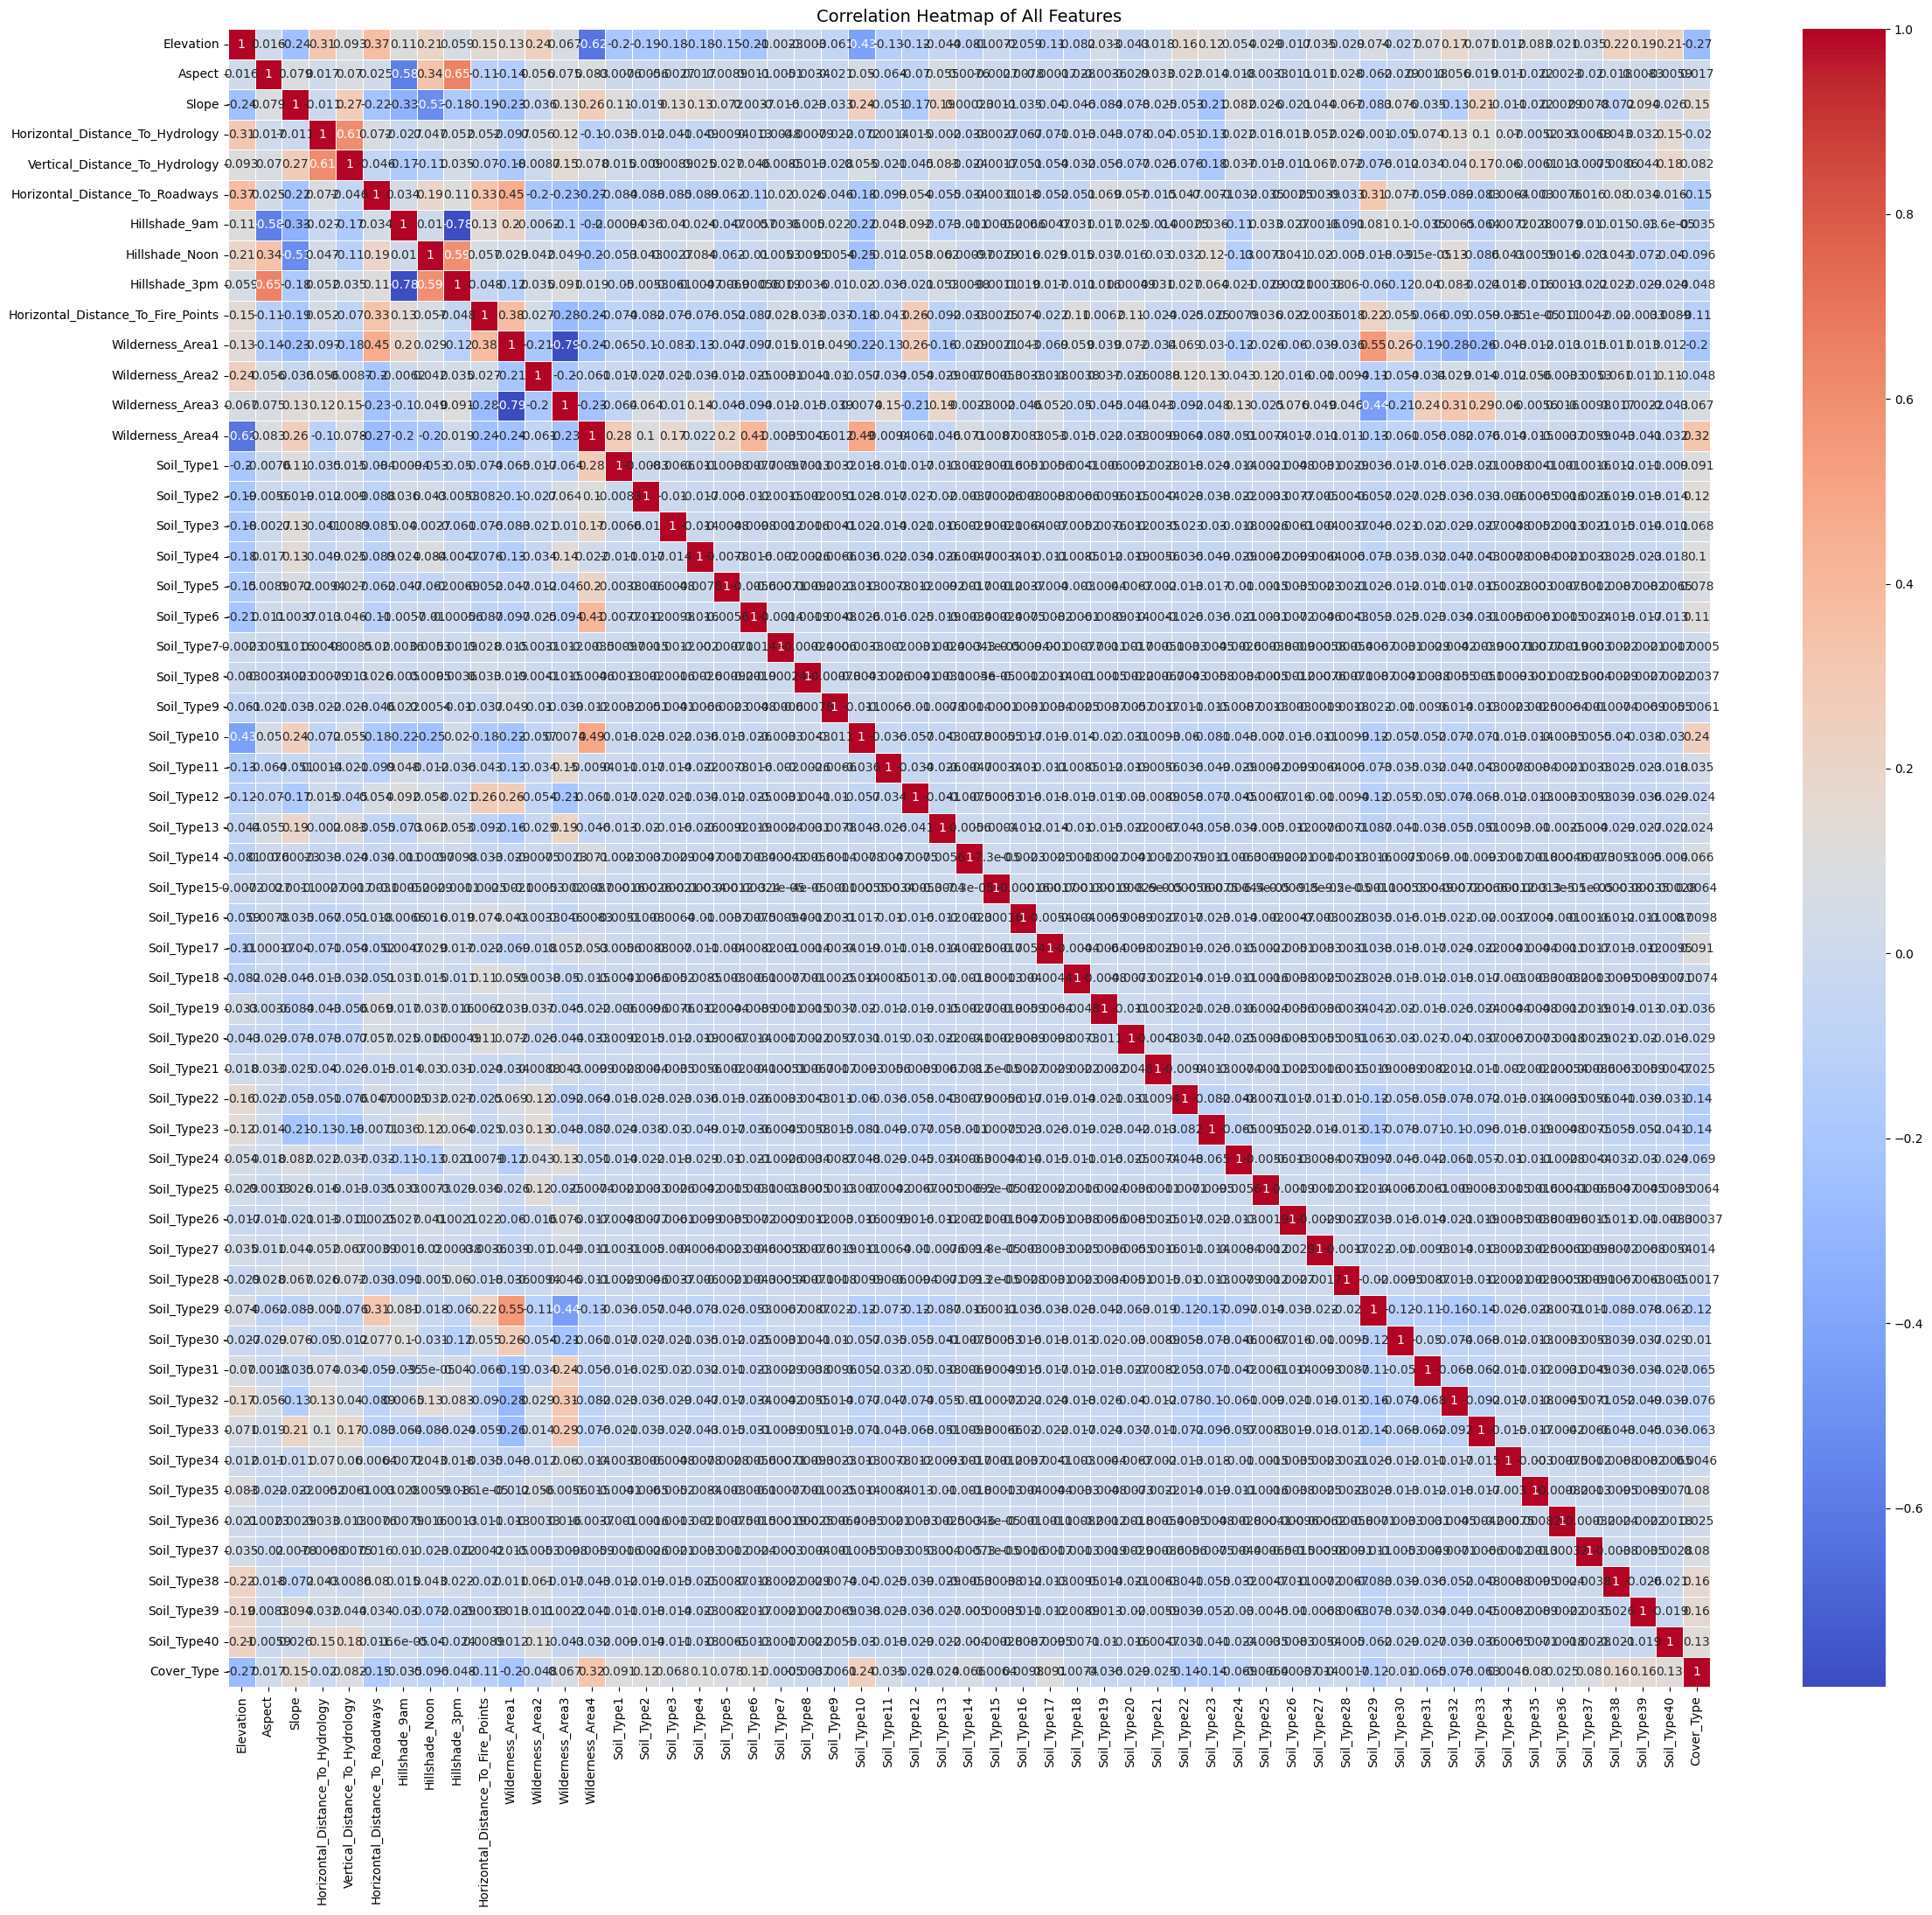

In [5]:
# Correlation Heatmap
corr_matrix = fct.corr(numeric_only=True)
plt.figure(figsize=(24, 22))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=14)
plt.tight_layout()
plt.show()

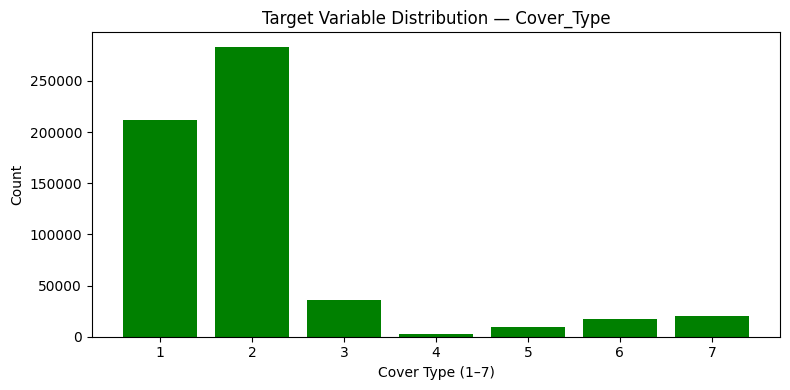

Class counts:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


In [6]:
# Target variable distribution - reveals class imbalance
target_var = fct['Cover_Type'].dropna()
plt.figure(figsize=(8, 4))
plt.bar(target_var.value_counts().sort_index().index,
        target_var.value_counts().sort_index().values, color='green')
plt.title('Target Variable Distribution — Cover_Type')
plt.xlabel('Cover Type (1–7)')
plt.ylabel('Count')
plt.xticks(range(1, 8))
plt.tight_layout()
plt.show()

print('Class counts:')
print(fct['Cover_Type'].value_counts().sort_index())

**Observation:** There is extreme class imbalance — classes 1 and 2 dominate while classes 3 and 7 are minorities. This is why we use SMOTE to handle it.

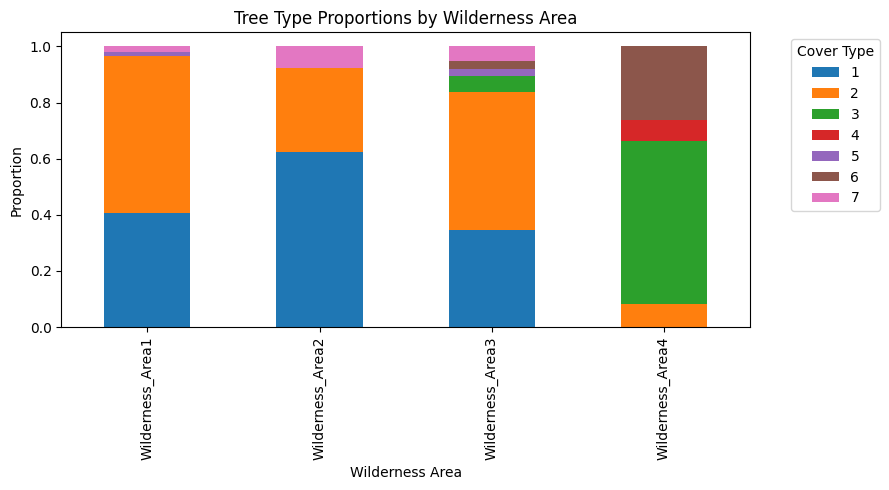

In [7]:
# Tree type proportions by Wilderness Area — directly answers research question
wilderness_cols = ['Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4']
fct['Wilderness_Area'] = fct[wilderness_cols].idxmax(axis=1)

ctab = pd.crosstab(fct['Wilderness_Area'], fct['Cover_Type'], normalize='index')
ctab.plot(kind='bar', stacked=True, figsize=(9, 5))
plt.title('Tree Type Proportions by Wilderness Area')
plt.xlabel('Wilderness Area')
plt.ylabel('Proportion')
plt.legend(title='Cover Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Train / Validation / Test Split (60 / 20 / 20)

In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# Drop derived string columns added during EDA
fct_cleaned = fct.dropna(subset=['Cover_Type'])
cols_to_drop = ['Wilderness_Area', 'Soil_Type']
fct_cleaned = fct_cleaned.drop(columns=[c for c in cols_to_drop if c in fct_cleaned.columns])

X = fct_cleaned.drop('Cover_Type', axis=1)
y = fct_cleaned['Cover_Type']   # Labels 1–7

# 80% train+val, 20% test — stratify to keep class balance
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
# 60% train, 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25, stratify=y_train_val, random_state=42
)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')

Train : (348606, 54)
Val   : (116203, 54)
Test  : (116203, 54)


## 4. Preprocessing Pipeline

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline

# All features are numeric
numeric_features = list(X_train.columns)

# Median imputation (robust to outliers) + StandardScaler
numeric_transformer = SkPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features)],
    remainder='drop'
)

# StratifiedKFold preserves class proportions in each fold
cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING      = 'f1_macro'   # best metric for imbalanced multiclass
RANDOM_STATE = 42

print('Preprocessing pipeline ready.')

Preprocessing pipeline ready.


## 5. Helper Functions

In [10]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, classification_report, confusion_matrix
)

def evaluate(name, model, X_eval, y_eval, offset=0):
    """Print full evaluation metrics for a fitted model."""
    y_pred = model.predict(X_eval)
    if offset:
        y_pred = y_pred + offset

    acc  = accuracy_score(y_eval, y_pred)
    bacc = balanced_accuracy_score(y_eval, y_pred)
    f1   = f1_score(y_eval, y_pred, average='macro')

    print(f'\n=== {name} ===')
    print(classification_report(y_eval, y_pred, digits=3))
    print(f'Accuracy         : {acc:.4f}')
    print(f'Balanced Accuracy: {bacc:.4f}')
    print(f'F1 Macro         : {f1:.4f}')
    print('\nConfusion Matrix:')
    print(confusion_matrix(y_eval, y_pred))
    return {'Accuracy': acc, 'Balanced_Acc': bacc, 'F1_Macro': f1}


def plot_cm(y_true, y_pred, title):
    """Plot a confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y_true.unique()),
                yticklabels=sorted(y_true.unique()))
    plt.title(f'Confusion Matrix — {title}', fontsize=12)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

print('Helper functions ready.')

Helper functions ready.


## 6. Best Model — SMOTE + Random Forest

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic samples for minority classes to balance the training set. Combined with Random Forest, this gave the highest validation F1 Macro across all strategies tested.

In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# ImbPipeline ensures SMOTE is applied ONLY inside each CV fold (prevents data leakage)
smote_rf_pipe = ImbPipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

smote_rf_params = {
    'smote__k_neighbors': [3, 5],
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
    'clf__max_features': ['sqrt', 'log2']
}

# RandomizedSearchCV is faster than GridSearchCV for large parameter spaces
smote_rf_search = RandomizedSearchCV(
    smote_rf_pipe,
    param_distributions=smote_rf_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

smote_rf_search.fit(X_train, y_train)
best_model = smote_rf_search.best_estimator_
best_model_name = 'SMOTE + Random Forest'

print('Best params:', smote_rf_search.best_params_)
print(f'Best CV F1 Macro: {smote_rf_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'smote__k_neighbors': 3, 'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Best CV F1 Macro: 0.9209


## 7. Validation Evaluation


=== SMOTE + Random Forest — VALIDATION ===
              precision    recall  f1-score   support

           1      0.959     0.941     0.950     42368
           2      0.955     0.959     0.957     56660
           3      0.937     0.958     0.947      7151
           4      0.881     0.907     0.894       549
           5      0.841     0.891     0.865      1899
           6      0.879     0.927     0.902      3474
           7      0.956     0.970     0.963      4102

    accuracy                          0.951    116203
   macro avg      0.916     0.936     0.926    116203
weighted avg      0.951     0.951     0.951    116203

Accuracy         : 0.9507
Balanced Accuracy: 0.9362
F1 Macro         : 0.9256

Confusion Matrix:
[[39883  2281     5     0    41    16   142]
 [ 1579 54359   208     1   261   211    41]
 [    1    44  6850    42    14   200     0]
 [    0     0    40   498     0    11     0]
 [   13   169    17     0  1692     7     1]
 [    4    35   189    24     2  3220

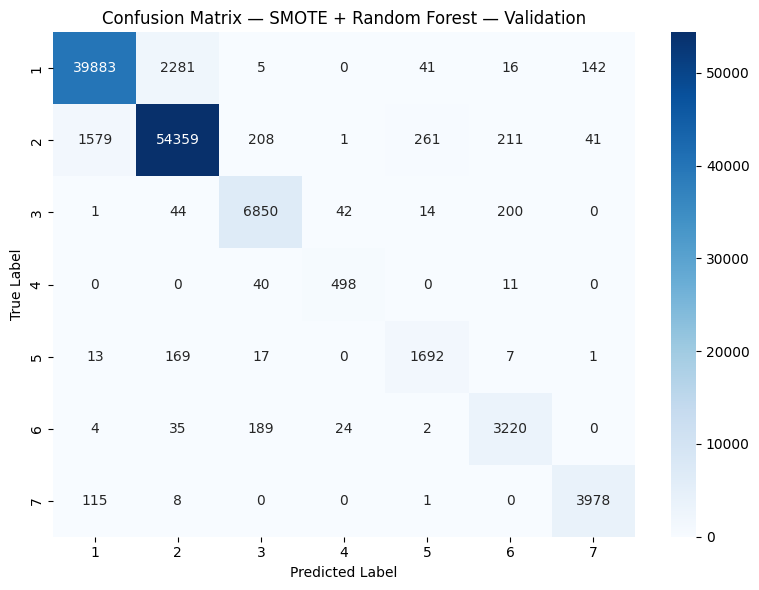

In [12]:
# Evaluate on validation set
val_metrics = evaluate('SMOTE + Random Forest — VALIDATION', best_model, X_val, y_val)
plot_cm(y_val, best_model.predict(X_val), 'SMOTE + Random Forest — Validation')

## 8. Multiple Random Seeds — Stability Check

Testing across 5 different random seeds confirms the model performs consistently and is not just lucky with seed=42.

In [13]:
SEEDS = [42, 0, 7, 123, 999]
seed_f1_scores = []

best_params = smote_rf_search.best_params_
k_nb         = best_params.get('smote__k_neighbors', 5)
clf_params   = {k.replace('clf__', ''): v for k, v in best_params.items() if k.startswith('clf__')}

for seed in SEEDS:
    Xtrv, Xte, ytrv, yte = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    Xtr, Xv, ytr, yv     = train_test_split(Xtrv, ytrv, test_size=0.25, stratify=ytrv, random_state=seed)

    srf = ImbPipeline([
        ('preprocess', preprocess),
        ('smote', SMOTE(k_neighbors=k_nb, random_state=seed)),
        ('clf', RandomForestClassifier(**clf_params, random_state=seed, n_jobs=-1))
    ])
    srf.fit(Xtr, ytr)
    score = f1_score(yv, srf.predict(Xv), average='macro')
    seed_f1_scores.append(score)
    print(f'  Seed {seed:>4}: F1 Macro = {score:.4f}')

print(f'\nAverage F1 Macro : {np.mean(seed_f1_scores):.4f}')
print(f'Std Dev          : {np.std(seed_f1_scores):.4f}')
print('\n✅ Low std deviation confirms the model is stable across different data splits.')

  Seed   42: F1 Macro = 0.9256
  Seed    0: F1 Macro = 0.9246
  Seed    7: F1 Macro = 0.9276
  Seed  123: F1 Macro = 0.9244
  Seed  999: F1 Macro = 0.9243

Average F1 Macro : 0.9253
Std Dev          : 0.0013

✅ Low std deviation confirms the model is stable across different data splits.


## 9. Permutation Feature Importance

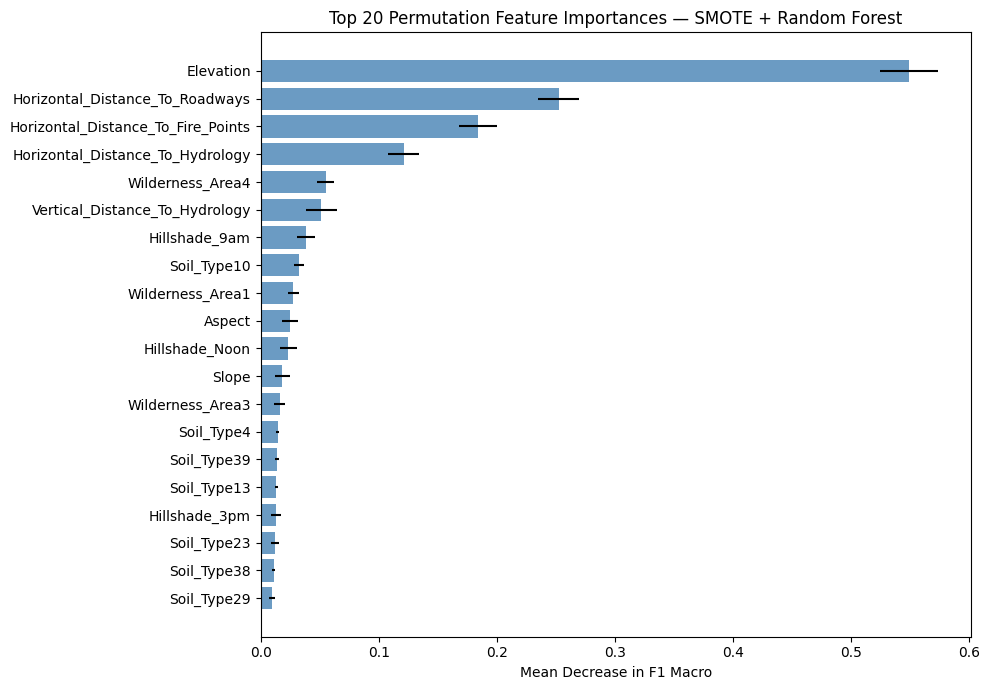

Top 10 most important features:
                           Feature  Importance      Std
                         Elevation    0.549041 0.024170
   Horizontal_Distance_To_Roadways    0.252369 0.017403
Horizontal_Distance_To_Fire_Points    0.183960 0.015814
  Horizontal_Distance_To_Hydrology    0.121074 0.012964
                  Wilderness_Area4    0.054948 0.006943
    Vertical_Distance_To_Hydrology    0.051232 0.012979
                     Hillshade_9am    0.038157 0.007639
                       Soil_Type10    0.032387 0.003844
                  Wilderness_Area1    0.027451 0.004664
                            Aspect    0.024898 0.007027


In [14]:
from sklearn.inspection import permutation_importance

# Sample 2000 rows from validation set for speed
X_val_sample = X_val.sample(min(2000, len(X_val)), random_state=42)
y_val_sample  = y_val.loc[X_val_sample.index]

perm_result = permutation_importance(
    best_model, X_val_sample, y_val_sample,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='f1_macro',
    n_jobs=1
)

perm_df = pd.DataFrame({
    'Feature':    X_val.columns,
    'Importance': perm_result.importances_mean,
    'Std':        perm_result.importances_std
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(perm_df['Feature'], perm_df['Importance'],
         xerr=perm_df['Std'], color='steelblue', alpha=0.8)
plt.gca().invert_yaxis()
plt.xlabel('Mean Decrease in F1 Macro')
plt.title('Top 20 Permutation Feature Importances — SMOTE + Random Forest')
plt.tight_layout()
plt.show()

print('Top 10 most important features:')
print(perm_df[['Feature','Importance','Std']].head(10).to_string(index=False))

## 10. Final Test Evaluation
The test set is only used once here at the very end — never during model selection or tuning.

====== SMOTE + Random Forest — FINAL TEST SET ======
              precision    recall  f1-score   support

           1      0.961     0.941     0.951     42368
           2      0.955     0.962     0.959     56661
           3      0.932     0.960     0.946      7151
           4      0.876     0.891     0.883       549
           5      0.874     0.897     0.885      1899
           6      0.888     0.922     0.905      3473
           7      0.951     0.966     0.959      4102

    accuracy                          0.952    116203
   macro avg      0.920     0.934     0.927    116203
weighted avg      0.952     0.952     0.952    116203

Accuracy         : 0.9517
Balanced Accuracy: 0.9341
F1 Macro         : 0.9267


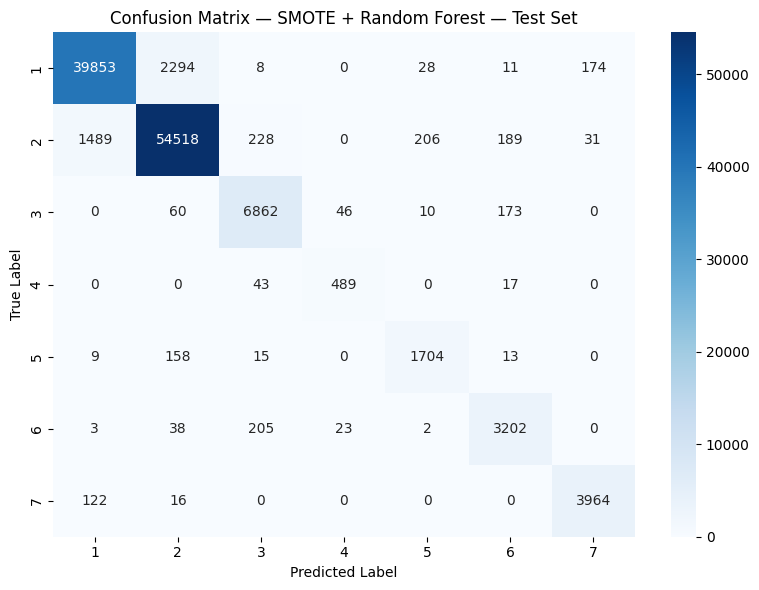

In [15]:
# Final evaluation on the held-out test set
y_test_pred = best_model.predict(X_test)

print(f'====== SMOTE + Random Forest — FINAL TEST SET ======')
print(classification_report(y_test, y_test_pred, digits=3))
print(f'Accuracy         : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.4f}')
print(f'F1 Macro         : {f1_score(y_test, y_test_pred, average="macro"):.4f}')

plot_cm(y_test, y_test_pred, 'SMOTE + Random Forest — Test Set')

## 11. Error Analysis

Top Confused Class Pairs (Test Set):
 True Class  Predicted As  Count
          1             2   2294
          2             1   1489
          2             3    228
          2             5    206
          6             3    205
          2             6    189
          1             7    174
          3             6    173
          5             2    158
          7             1    122
          3             2     60
          3             4     46
          4             3     43
          6             2     38
          2             7     31


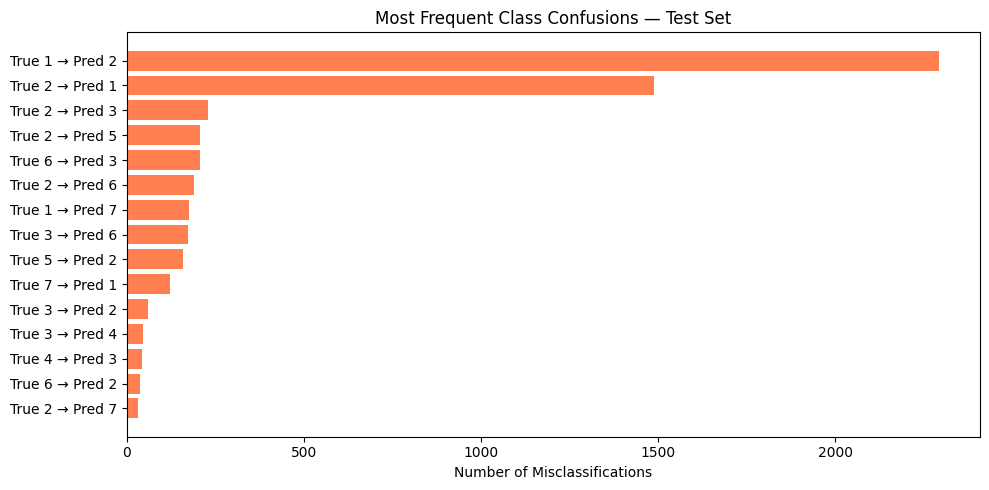

In [16]:
# Identify most confused class pairs
cm_test = confusion_matrix(y_test, y_test_pred)
labels  = sorted(y_test.unique())

confused_pairs = []
for i, true_lbl in enumerate(labels):
    for j, pred_lbl in enumerate(labels):
        if i != j and cm_test[i, j] > 0:
            confused_pairs.append({
                'True Class': true_lbl,
                'Predicted As': pred_lbl,
                'Count': cm_test[i, j]
            })

confused_df = pd.DataFrame(confused_pairs).sort_values('Count', ascending=False).head(15)
print('Top Confused Class Pairs (Test Set):')
print(confused_df.to_string(index=False))

plt.figure(figsize=(10, 5))
confused_df['Pair'] = 'True ' + confused_df['True Class'].astype(str) + \
                      ' → Pred ' + confused_df['Predicted As'].astype(str)
plt.barh(confused_df['Pair'], confused_df['Count'], color='coral')
plt.gca().invert_yaxis()
plt.xlabel('Number of Misclassifications')
plt.title('Most Frequent Class Confusions — Test Set')
plt.tight_layout()
plt.show()

## 12. Explainability (SHAP)

In [17]:
import shap

# Use 500 samples from test set for speed
X_shap_sample = X_test.sample(500, random_state=42)

# Extract preprocessed data and classifier from pipeline
step_names         = list(best_model.named_steps.keys())
X_shap_transformed = best_model.named_steps[step_names[0]].transform(X_shap_sample)
clf_model          = best_model.named_steps[step_names[-1]]
feature_names      = list(X_shap_sample.columns)

# TreeExplainer is exact and fast for tree-based models
explainer   = shap.TreeExplainer(clf_model)
shap_values = explainer.shap_values(X_shap_transformed)

print('SHAP values computed successfully.')
print(f'Number of classes : {len(shap_values)}')
print(f'Shape per class   : {shap_values[0].shape}')

SHAP values computed successfully.
Number of classes : 500
Shape per class   : (54, 7)


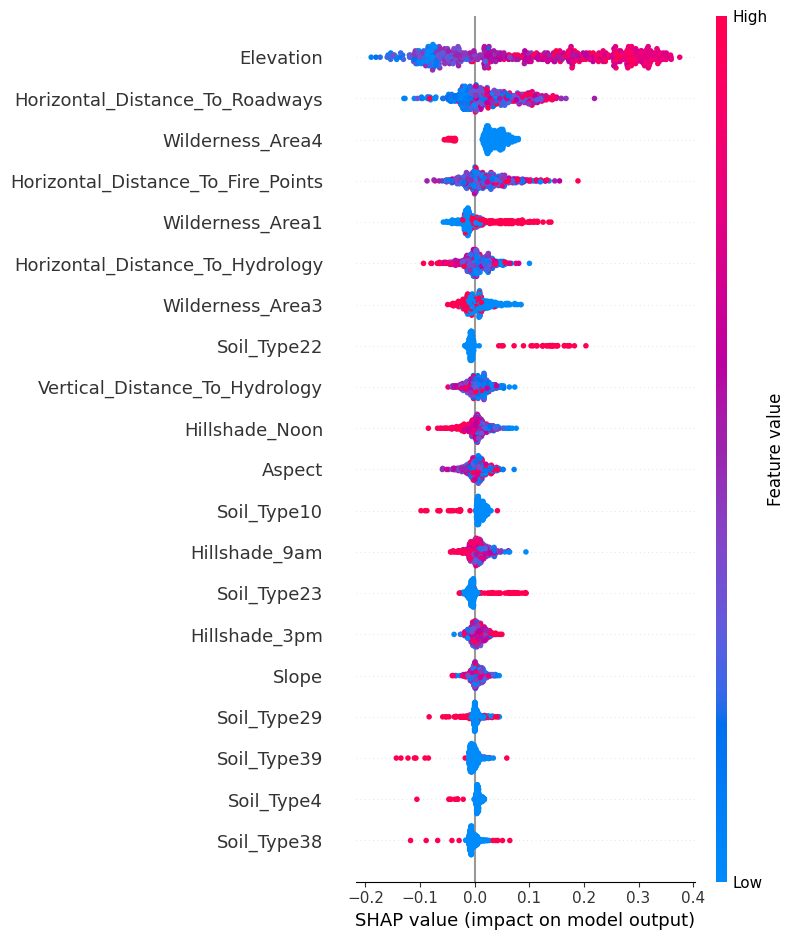

In [19]:
# SHAP Beeswarm — shows which features matter AND direction of effect
# Using Class 1 (Spruce/Fir) as the representative example
shap.summary_plot(
    shap_values[:, :, 0], # Select SHAP values for the first class (Cover_Type 1)
    X_shap_transformed,
    feature_names=feature_names,
    plot_type='dot',
    max_display=20,
    show=True
)

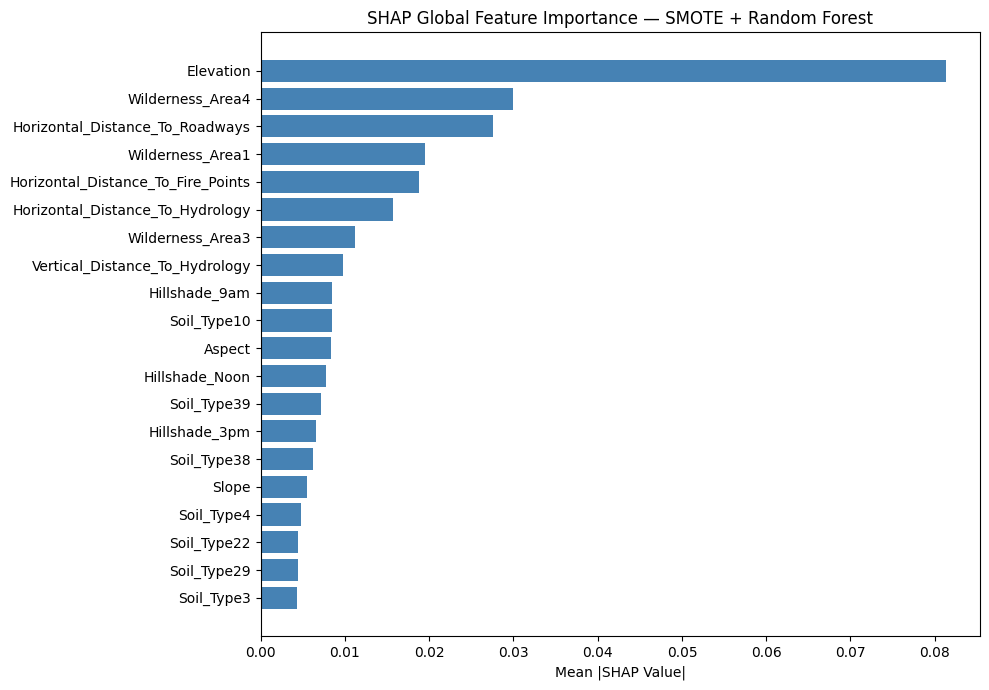

Top 10 features:
                           Feature  Mean |SHAP|
                         Elevation     0.081311
                  Wilderness_Area4     0.029943
   Horizontal_Distance_To_Roadways     0.027543
                  Wilderness_Area1     0.019488
Horizontal_Distance_To_Fire_Points     0.018752
  Horizontal_Distance_To_Hydrology     0.015755
                  Wilderness_Area3     0.011172
    Vertical_Distance_To_Hydrology     0.009743
                     Hillshade_9am     0.008439
                       Soil_Type10     0.008416


In [21]:
# SHAP Global Bar Plot — mean absolute SHAP per feature across all classes
mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 2))

shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(shap_importance_df['Feature'], shap_importance_df['Mean |SHAP|'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP Value|')
plt.title('SHAP Global Feature Importance — SMOTE + Random Forest')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(shap_importance_df.head(10).to_string(index=False))

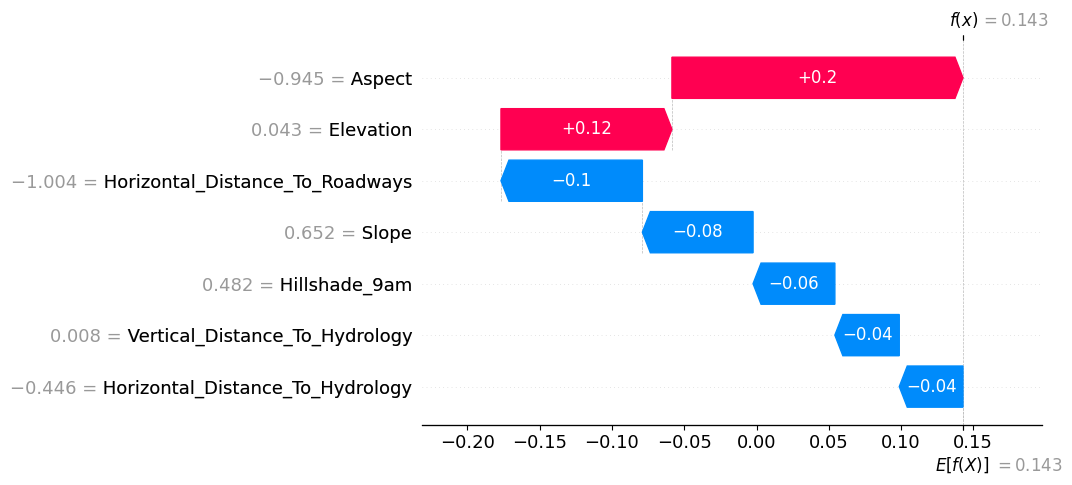

In [22]:
# SHAP Waterfall — explains a single prediction (local explanation)
shap_explanation = shap.Explanation(
    values=shap_values[0][0],
    base_values=explainer.expected_value[0],
    data=X_shap_transformed[0],
    feature_names=feature_names
)
shap.plots.waterfall(shap_explanation, max_display=15, show=True)

## 13. Save Model for Deployment
Run this cell last! It saves the trained model to a file that the Streamlit app will load.

In [23]:
import joblib
import os

# Save the full pipeline (preprocessing + SMOTE + Random Forest)
joblib.dump(best_model, 'best_model.joblib')

# Save the model name for reference
with open('best_model_name.txt', 'w') as f:
    f.write(best_model_name)

print('Model saved successfully!')
print(f'   Model name : {best_model_name}')
print(f'   File size  : {os.path.getsize("best_model.joblib") / 1024:.1f} KB')
print()
print('Next step: copy best_model.joblib into the same folder as app.py')
print('   Then run:  streamlit run app.py')

Model saved successfully!
   Model name : SMOTE + Random Forest
   File size  : 3420146.1 KB

Next step: copy best_model.joblib into the same folder as app.py
   Then run:  streamlit run app.py
